<!--
Software Name : learning-parities-with-product-networks
SPDX-FileCopyrightText: Copyright (c) 2026 Orange S.A.
SPDX-License-Identifier: MIT

This software is distributed under the MIT License .,
see the "LICENSE.md" file for more details or https://opensource.org/licenses/MIT

Author: Guillaume Larue, guillaume.larue@orange.com
Software description: Source code of the paper "Learning High-Dimensional Parity Functions with Product Networks"
-->

# Study C — Impact of Learning Rate $\alpha$ on Convergence

Explores how the learning rate $\alpha$ affects convergence for several problem sizes $N$, under unit sparsity ($p_e = 1/N$). Compares empirical behaviour with the theoretical convergence bounds $\alpha_0$, $\alpha_1$, $\alpha_2$.

**Data generated by:** [run_study_C.py](../studies/run_study_C.py)  
**Paper section:** Appendix G.4 — Additional Learning Rate Analysis (Figures 24 and 25)


| Parameter | Value |
|-----------|-------|
| Problem Size $N$          | 100 |
| Num. Parallel Nodes $P$   | 10 |
| Learning Rate $\alpha$    | [0.01, 100]  (50 values, log-spaced)           |
| Batch Size $M$            | 50000         |
| Bernouilli Prob. $p_e$    | $1/N$  |
| Max. Steps $S$            | 10000         | 
| Oracle Proportion $p_w$   | 0.5           |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import sys
import os
import glob

# Add parent directory to path
sys.path.append('..')

from plotting.plot_utility import plot_metric_vs_param, compute_steps_to_thresholds, setup_plot_style

%matplotlib inline
setup_plot_style()

In [2]:
def get_latest_study_folder(study_prefix):
    pattern = f'../studies/results/{study_prefix}_*/'
    folders = glob.glob(pattern)
    if folders:
        return max(folders)  # Latest by name (timestamp-based)
    return None

mode = 'auto'  # Change to 'manual' to specify your own path

if mode == 'auto':
    results_dir = get_latest_study_folder('C_alpha_impact')
    if results_dir is None:
        raise FileNotFoundError("No Study C results found. Run run_study_C.py first.")
    print(f"Auto-detected folder: {results_dir}")
else:
    results_dir = '../studies/results/C_alpha_impact_XXXXXX_XXXXXX/'
    print(f"Using manual path: {results_dir}")

alpha_values = np.load(results_dir + 'alpha_values.npy')
p_diff_matrix = np.load(results_dir + 'p_diff_matrix.npy')
steps_to_convergence = np.load(results_dir + 'steps_to_convergence.npy')

print(f"\nalpha range: {alpha_values[0]:.6f} to {alpha_values[-1]:.6f}")
print(f"Number of alpha values: {len(alpha_values)}")
print(f"p_diff_matrix shape: {p_diff_matrix.shape}")

# Identify optimal and first-diverging alpha indices
optimal_steps = +np.inf
alpha_id_optimal = None
alpha_id_first_divergence = None
for alpha_id in range(len(alpha_values)):
    p_diff_at_alpha = p_diff_matrix[alpha_id, :]
    for i in range(len(p_diff_at_alpha)):
        if i > 0:
            if np.isnan(p_diff_at_alpha[i]) or p_diff_at_alpha[i] > p_diff_at_alpha[i-1]:
                if alpha_id_first_divergence is None:
                    alpha_id_first_divergence = alpha_id
                break
            if p_diff_at_alpha[i] < 0.025:
                if i < optimal_steps:
                    optimal_steps = i
                    alpha_id_optimal = alpha_id
                break

print(f"Optimal alpha_id : {alpha_id_optimal}, alpha_value: {alpha_values[alpha_id_optimal]:.6f}")
print(f"First alpha_id with divergence: {alpha_id_first_divergence}, alpha_value: {alpha_values[alpha_id_first_divergence]:.6f}\n")

# Theoretical bounds
n = 100
# sigma convergence bound \frac{x}{2}e^{-\frac{79x-9}{32x-72}}
bound_1 = (n) * np.exp(-(72 * n - 9) / (32 * n - 72))
# monotonic behaviour bound: \frac{x}{2}e^{-\frac{79x-9}{32x-72}}
bound_2 = (n / 2) * np.exp(-(72 * n - 9) / (32 * n - 72))
# Bounded convergence interval bound: N \times \frac{3 - 2e^{+\varepsilon(N)}}{4\times \left[\frac{3}{2} e^{9/4} e^{\eta^{(\xi)}_{\max}(N)} - e^{-1} e^{-\eta^{(\zeta)}_{\max}(N)}\right]} 
epsilon = (402*n-216)/(2*n*(32*n-72))
eta_xi_max = 153/(32*n-72)
eta_zeta_max = 3/(2*n)
bound_3 = n * (3 - 2 * np.exp(+epsilon)) / (4 * (1.5 * np.exp(9 / 4) * np.exp(+eta_xi_max) - np.exp(-1) * np.exp(-eta_zeta_max)))
print(f"Theoretical bounds:\n  Bound 1 (sigma convergence): {bound_1:.6f}\n  Bound 2 (monotonic behaviour): {bound_2:.6f}\n  Bound 3 (bounded convergence interval): {bound_3:.6f}\n")

Auto-detected folder: ../studies/results/C_alpha_impact_20260420_200913/

alpha range: 0.010000 to 100.000000
Number of alpha values: 50
p_diff_matrix shape: (50, 10000)
Optimal alpha_id : 44, alpha_value: 39.069399
First alpha_id with divergence: 46, alpha_value: 56.898660

Theoretical bounds:
  Bound 1 (sigma convergence): 10.036788
  Bound 2 (monotonic behaviour): 5.018394
  Bound 3 (bounded convergence interval): 1.488074



## Error $p_\text{diff}$ vs $\alpha$ — Iso-Step Curves

Each curve corresponds to a fixed number of training steps. The theoretical convergence/divergence boundaries $\alpha_0$, $\alpha_1$, $\alpha_2$ derived in §4.3 are overlaid as vertical reference lines. The red hatched zone denote the zone where there is no convergence in the considered max number of steps $S=10000$

See Paper Appendix G.4. Figure 24


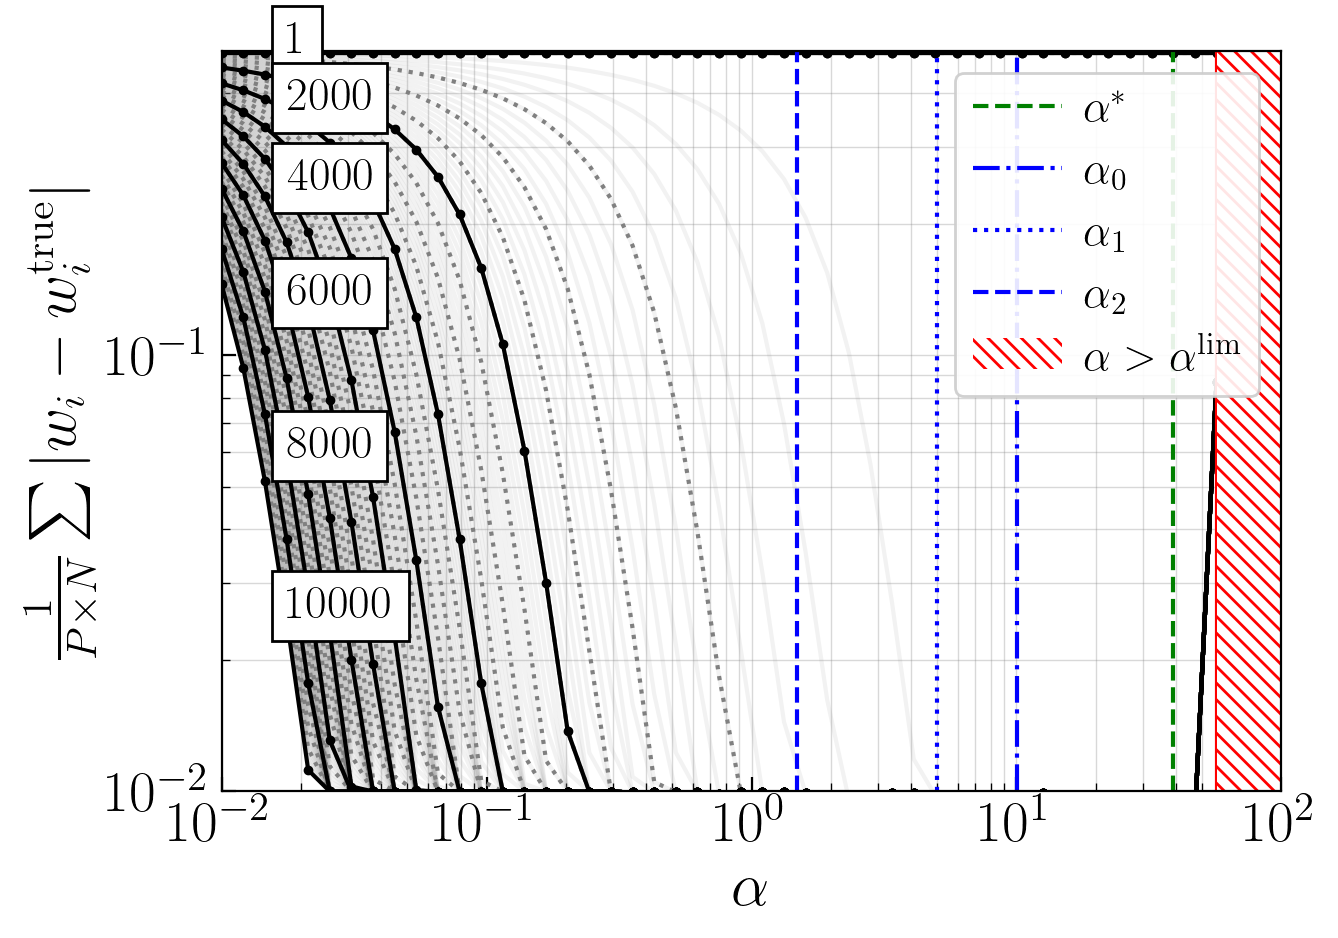

In [3]:
fig, ax = plt.subplots()

p_diff_matrix = np.clip(p_diff_matrix, None, 0.5)

plot_metric_vs_param(
    alpha_values,
    p_diff_matrix,
    ax,
    draw_best=False,
    add_min_curve=False,
    xscale='log',
    yscale='log'
)

ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('$\\frac{1}{P \\times N}\sum|w_i-w_i^\mathrm{true}|$')

ax.set_ylim(bottom=0.01, top=0.5)
ax.set_xlim(left=1e-2, right=1e2)
ax.axvline(x=alpha_values[alpha_id_first_divergence], color='red', linestyle='-')
ax.axvline(x=alpha_values[alpha_id_optimal], color='green', linestyle='--', label="$\\alpha^*$")
ax.axvline(x=bound_1, color='blue', linestyle='-.', label='$\\alpha_0$')
ax.axvline(x=bound_2, color='blue', linestyle=':', label='$\\alpha_1$')
ax.axvline(x=bound_3, color='blue', linestyle='--', label='$\\alpha_2$')
p = patches.Rectangle((alpha_values[alpha_id_first_divergence],0), 100, 1, linewidth=0, fill=True, fc='white', ec='red', hatch='\\\\\\\\',zorder=2, label='$\\alpha>\\alpha^\\mathrm{lim}$')
ax.add_patch(p)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Steps to Convergence vs $\alpha$ — Iso-$p_\text{diff}$ Curves

Each curve shows the number of steps required to reach a given $p_\text{diff}$ threshold as a function of $\alpha$. One can see a clear linear relationship between $\alpha$ and the convergence speed, until reaching the $\alpha^\text{lim}$ threshold where the convergence suddently breaks.

See Paper Appendix G.4. Figure 25


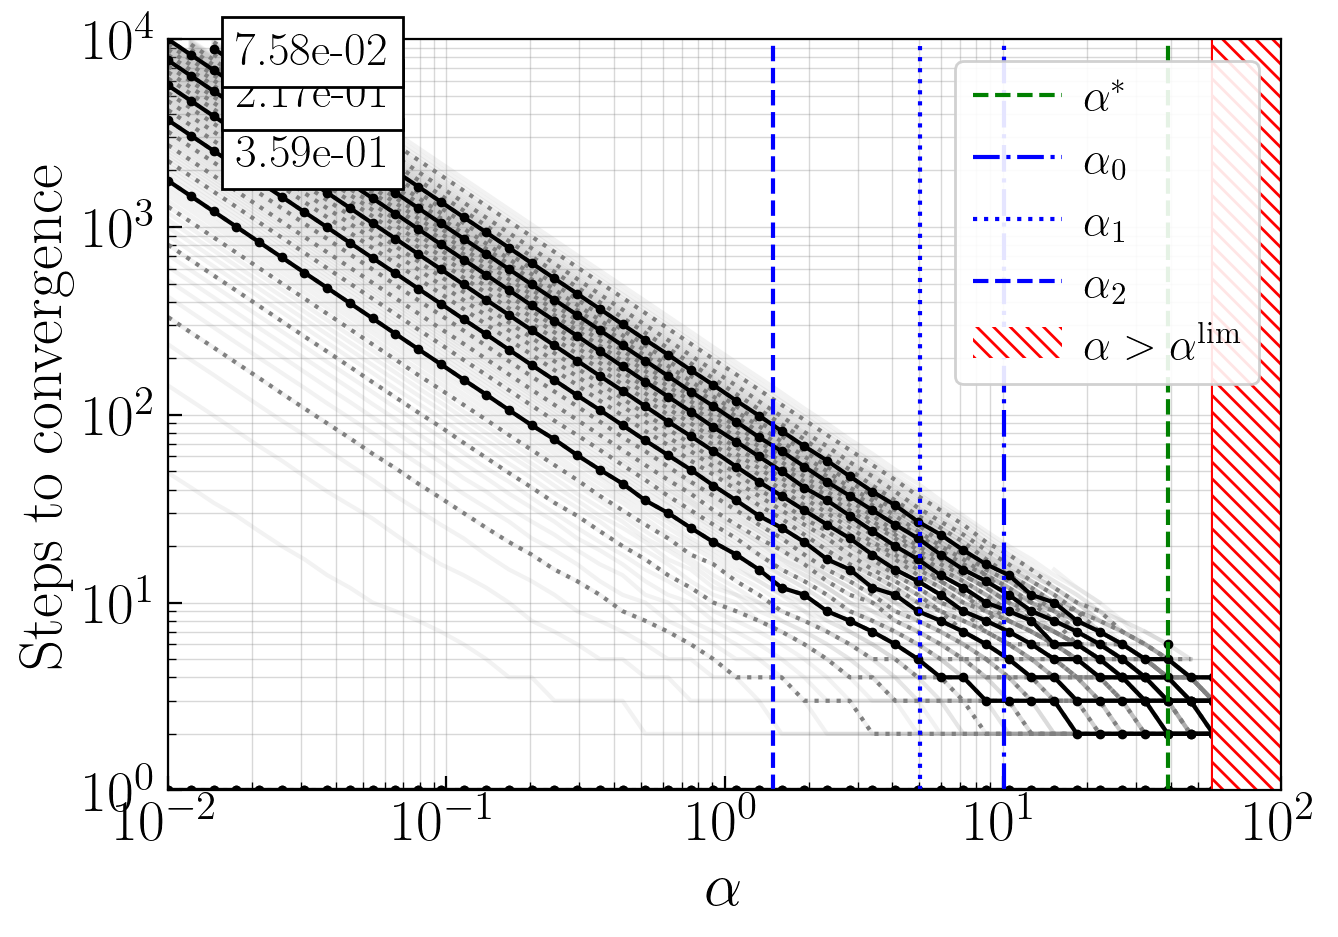

In [4]:
thresholds, steps_data = compute_steps_to_thresholds(alpha_values, p_diff_matrix, n_thresholds=700)

fig, ax = plt.subplots()

plot_metric_vs_param(
    alpha_values,
    steps_data+1,
    ax,
    draw_best=False,
    xscale='log',
    yscale='log',
    xlim=(1e-2, 1e2),
    ylim=(1, 10000),
    value_labels=thresholds,
    add_min_curve=False
)

ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('Steps to convergence')

ax.axvline(x=alpha_values[alpha_id_first_divergence], color='red', linestyle='-')
ax.axvline(x=alpha_values[alpha_id_optimal], color='green', linestyle='--', label="$\\alpha^*$")
ax.axvline(x=bound_1, color='blue', linestyle='-.', label='$\\alpha_0$')
ax.axvline(x=bound_2, color='blue', linestyle=':', label='$\\alpha_1$')
ax.axvline(x=bound_3, color='blue', linestyle='--', label='$\\alpha_2$')
p = patches.Rectangle((alpha_values[alpha_id_first_divergence],0), 100, 10000, linewidth=0, fill=True, fc='white', ec='red', hatch='\\\\\\\\',zorder=2, label='$\\alpha>\\alpha^\\mathrm{lim}$')

ax.add_patch(p)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()